# Variable Encoding
- encode the text variables
- use google model to turn words/sentences into 300 dimensios vector
- remove all the features with no relevance -> all embeddings with 0
- create and use autoencoder to turn 300 dimension vectors (or new lenght vector) into 5 word vectors
- compute cosine similarity to understand the vectors

## Imports

In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import tensorflow_hub as hub
from sklearn.metrics.pairwise import cosine_similarity

notebook_dir = os.getcwd()
model_path = notebook_dir + "/../models/"

## Read dataset

In [17]:
data = pd.read_csv("../data/interim/07. FRAIL_null_treatment.csv")
print(data.shape)
data = data.fillna("")
data.head()

(6705, 70)


,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,...,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,HANDGRIP_DIREITA_tentativa_2
0,19,1,1,2021-11-16,1941-08-20,80,0,1,2,153.0,...,1,0,16,1,1,1,1,2,80,12.0
1,19,3,1,2022-11-16,1941-08-20,81,0,1,2,152.0,...,1,0,20,2,2,2,2,1,80,12.9
2,37,1,1,2021-11-16,1948-11-20,72,0,1,2,149.0,...,1,0,20,1,1,1,1,2,100,22.9
3,37,2,1,2022-06-29,1948-11-20,73,0,1,2,150.0,...,1,0,22,2,1,1,1,1,100,15.7
4,37,3,1,2022-11-16,1948-11-20,73,0,1,2,148.0,...,1,0,23,1,1,1,1,1,70,15.1


## Prepare data

In [18]:
data.select_dtypes(include='object').head()

,Data_avaliacao,Data_nascimento,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu
0,2021-11-16,1941-08-20,caminhar,ferida,joelho,,
1,2022-11-16,1941-08-20,caminhar,não sabe,anca,,
2,2021-11-16,1948-11-20,,,,,
3,2022-06-29,1948-11-20,,,,,
4,2022-11-16,1948-11-20,,,,,


In [19]:
text_columns = ["Quedas_12meses_Situacao", "Quedas_12meses_Lesao_Tipo", "Quedas_12meses_Lesao_Local", "@6_MIN_ANDAR_Parou_Motivo", "@6_MIN_ANDAR_Desistiu"]

In [20]:
data_text = data[text_columns].copy()
data_text.head()

,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu
0,caminhar,ferida,joelho,,
1,caminhar,não sabe,anca,,
2,,,,,
3,,,,,
4,,,,,


In [21]:
data_text = data_text.map(lambda x: x.lower() if isinstance(x, str) else x)
data_text.head()

,Quedas_12meses_Situacao,Quedas_12meses_Lesao_Tipo,Quedas_12meses_Lesao_Local,@6_MIN_ANDAR_Parou_Motivo,@6_MIN_ANDAR_Desistiu
0,caminhar,ferida,joelho,,
1,caminhar,não sabe,anca,,
2,,,,,
3,,,,,
4,,,,,


## String embeddings

In [22]:
# Setup
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

def encode_series(series: pd.Series,
                  model,
                  batch_size: int = 128,
                  normalize: bool = True,
                  dtype: str = "float32"):
    """
    Returns an (N, d) numpy array for the given text series.
    Deduplicates strings to avoid recomputing embeddings for repeats.
    """
    # to strings, replace NaN with empty
    texts = series.fillna("").astype(str).tolist()

    # map each unique text to its embedding
    uniq_texts = list(dict.fromkeys(texts))  # preserves order, removes dups

    emb_uniq_list = []
    for i in range(0, len(uniq_texts), batch_size):
        batch = uniq_texts[i:i+batch_size]
        batch_emb = model(batch).numpy()
        emb_uniq_list.append(batch_emb)

    emb_uniq = np.vstack(emb_uniq_list)

    if normalize:
        emb_uniq = emb_uniq / np.linalg.norm(emb_uniq, axis=1, keepdims=True)

    lookup = {t: e for t, e in zip(uniq_texts, emb_uniq)}
    out = np.stack([lookup[t] for t in texts])

    return out

#  Compute & attach embeddings efficiently
for col in text_columns:
    emb = encode_series(data_text[col], embed, batch_size=256, normalize=True, dtype="float32")
    data_text[f"{col}_embedding"] = list(emb)         

In [23]:
# Reduzir embeddings de todas as colunas de texto
n_components = 10

data_out = data.copy()
svd_models = {}

for col in text_columns:
    emb_col = f"{col}_embedding"

    X = np.vstack(data_text[emb_col].values)

    # treinar SVD para esta coluna
    svd_col = TruncatedSVD(n_components=n_components, n_iter=7, random_state=0)
    X_10 = svd_col.fit_transform(X).astype("float32")   # (N, 10)
    svd_models[col] = svd_col

    # criar colunas numéricas no dataset final
    emb10_cols = [f"{col}_emb10_{i+1}" for i in range(n_components)]
    data_out[emb10_cols] = X_10

    print(f"{col}: explained variance (10D) = {svd_col.explained_variance_ratio_.sum():.3f}")

Quedas_12meses_Situacao: explained variance (10D) = 0.915
Quedas_12meses_Lesao_Tipo: explained variance (10D) = 0.931
Quedas_12meses_Lesao_Local: explained variance (10D) = 0.830
@6_MIN_ANDAR_Parou_Motivo: explained variance (10D) = 0.891
@6_MIN_ANDAR_Desistiu: explained variance (10D) = 0.886


Top 10 labels (mais frequentes):
 - : 5141
 - caminhar: 610
 - escadas: 173
 - tropeçar: 173
 - não sabe: 119
 - escorregar: 94
 - desiquilíbrio: 41
 - quintal: 35
 - cama: 17
 - escadote: 13

Explained variance (tSVD, 10D): 0.915


C:\Users\HP\AppData\Local\Temp\ipykernel_23084\381721069.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top
C:\Users\HP\AppData\Local\Temp\ipykernel_23084\381721069.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top


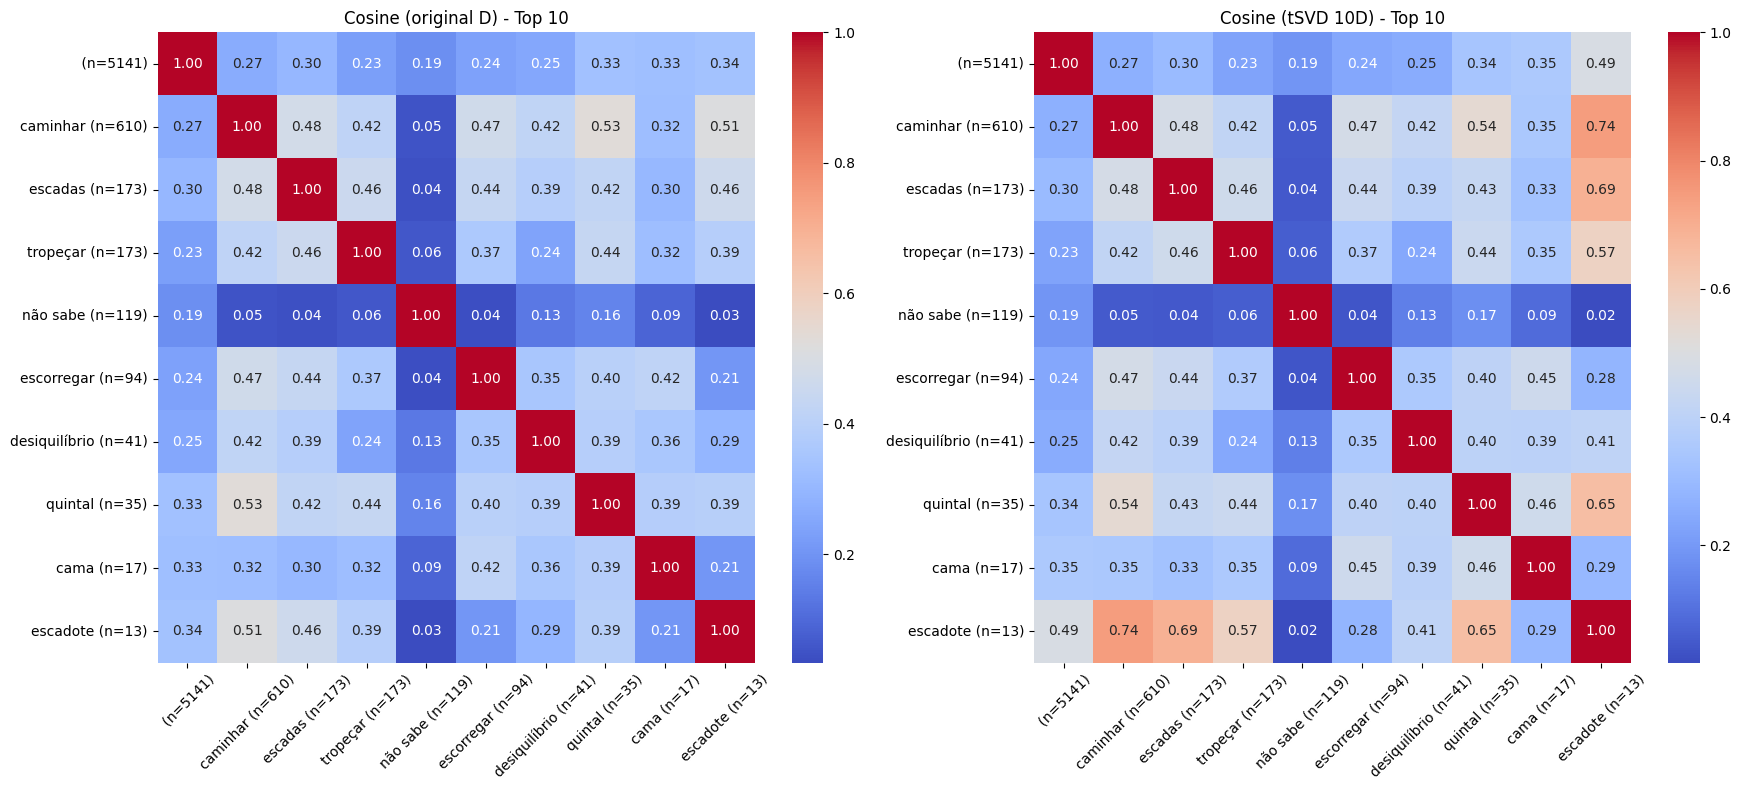

In [ ]:
# Heatmaps
target_col = "Quedas_12meses_Situacao"
emb_col = f"{target_col}_embedding"
top_n = 10


svd = svd_models[target_col]
n_components = svd.n_components
df = data_text[[target_col, emb_col]].dropna(subset=[target_col]).copy()

# 1) TOP 10 strings mais frequentes
counts = df[target_col].value_counts()
top_labels = counts.head(top_n).index.tolist()
df_top = df[df[target_col].isin(top_labels)].copy()


df_top[target_col] = pd.Categorical(df_top[target_col], categories=top_labels, ordered=True)
df_top = df_top.sort_values(target_col)

# 2) Espaço original (D): média dos embeddings por label
grouped = (
    df_top
    .groupby(target_col, sort=False)[emb_col]
    .apply(lambda emb_list: np.vstack(emb_list.tolist()).mean(axis=0))
)

labels = grouped.index.tolist()
embedding_matrix = np.vstack(grouped.values)  # (n_labels, D)

# 3) Espaço reduzido 
grouped_svd = (
    df_top
    .groupby(target_col, sort=False)[emb_col]
    .apply(lambda emb_list: svd.transform(np.vstack(emb_list.tolist())).mean(axis=0))
    .reindex(labels)
)

# 4) Cosine matrices
E_k = np.vstack(grouped_svd.values)    # (n_labels, k)
E_k = normalize(E_k)
S_k = cosine_similarity(E_k)

E300 = normalize(embedding_matrix)     # (n_labels, D)
S300 = cosine_similarity(E300)

print(f"\nExplained variance (tSVD, {n_components}D): {svd.explained_variance_ratio_.sum():.3f}")

labels_with_n = [f"{lab} (n={int(counts.loc[lab])})" for lab in labels]
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    S300, ax=axes[0],
    xticklabels=labels_with_n, yticklabels=labels_with_n,
    cmap='coolwarm', annot=True, fmt=".2f"
)
axes[0].set_title("Cosine (original D) - Top 10")
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    S_k, ax=axes[1],
    xticklabels=labels_with_n, yticklabels=labels_with_n,
    cmap='coolwarm', annot=True, fmt=".2f"
)
axes[1].set_title(f"Cosine (tSVD {n_components}D) - Top 10")
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [25]:
# Guardar
out_csv = "../data/interim/07_FRAIL_with_all_emb10.csv"
data_out.to_csv(out_csv, index=False)